In [1]:
import pandas as pd

path = r"C:\Users\Dell\Documents\ANALYTICS PRACTICE\PROJECT\HealthCare Project\hospital_readmission_dataset.csv"
df = pd.read_csv(path)

# Display the first 5 rows
df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [2]:
import pandas as pd
import numpy as np

path = r"C:\Users\Dell\Documents\ANALYTICS PRACTICE\PROJECT\HealthCare Project\hospital_readmission_dataset.csv"
df = pd.read_csv(path)

# Check data types and missing values
print("--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   str    
 1   admission_date             8000 non-null   str    
 2   season                     8000 non-null   str    
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   str    
 5   region                     8000 non-null   str    
 6   primary_diagnosis          8000 non-null   str    
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   str    
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null 

In [3]:
df['admission_date'] = pd.to_datetime(df['admission_date'], dayfirst=True)

df['readmission_risk_score'] = df['readmission_risk_score'].fillna(df['readmission_risk_score'].median())

df = df.drop_duplicates()

print("Cleaning complete. Dates converted and duplicates removed.")

Cleaning complete. Dates converted and duplicates removed.


C:\Users\Dell\AppData\Local\Temp\ipykernel_20388\3973813909.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['admission_date'] = pd.to_datetime(df['admission_date'], dayfirst=True)


In [4]:
def categorize_risk(score):
    if score >= 0.8: return 'High Risk'
    elif score >= 0.5: return 'Medium Risk'
    else: return 'Low Risk'

df['risk_level'] = df['readmission_risk_score'].apply(categorize_risk)

# Calculate "Potential Cost Impact" (Hypothetical)
# Let's assume an average readmission costs the hospital $15,000
df['potential_savings'] = df['readmission_risk_score'].apply(lambda x: 15000 if x > 0.85 else 0)

df['admission_month'] = df['admission_date'].dt.month_name()
df['admission_year'] = df['admission_date'].dt.year

print("Calculations complete. New columns: risk_level, potential_savings, admission_month.")

Calculations complete. New columns: risk_level, potential_savings, admission_month.


In [5]:
# Which Diagnosis has the highest average risk?
diagnosis_risk = df.groupby('primary_diagnosis')['readmission_risk_score'].mean().sort_values(ascending=False)
print("--- Average Risk by Diagnosis ---")
print(diagnosis_risk)

# Which Insurance Type has the most high-risk patients?
insurance_impact = pd.crosstab(df['insurance_type'], df['risk_level'])
print("\n--- Insurance vs Risk Level ---")
print(insurance_impact)

--- Average Risk by Diagnosis ---
primary_diagnosis
Heart Failure     0.876526
COPD              0.865704
Sepsis            0.854789
Stroke            0.854451
Kidney Disease    0.850518
Influenza         0.737167
Appendicitis      0.723577
Pneumonia         0.722000
Fracture          0.717857
Hypertension      0.703374
Diabetes          0.699939
Name: readmission_risk_score, dtype: float64

--- Insurance vs Risk Level ---
risk_level      High Risk  Low Risk  Medium Risk
insurance_type                                  
Medicaid              585       311          702
Medicare             2460         0           82
Private              1014       764         1274
Uninsured             397        93          318


C:\Users\Dell\AppData\Local\Temp\ipykernel_20388\1531715900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age_group', y='readmission_risk_score', palette='viridis')


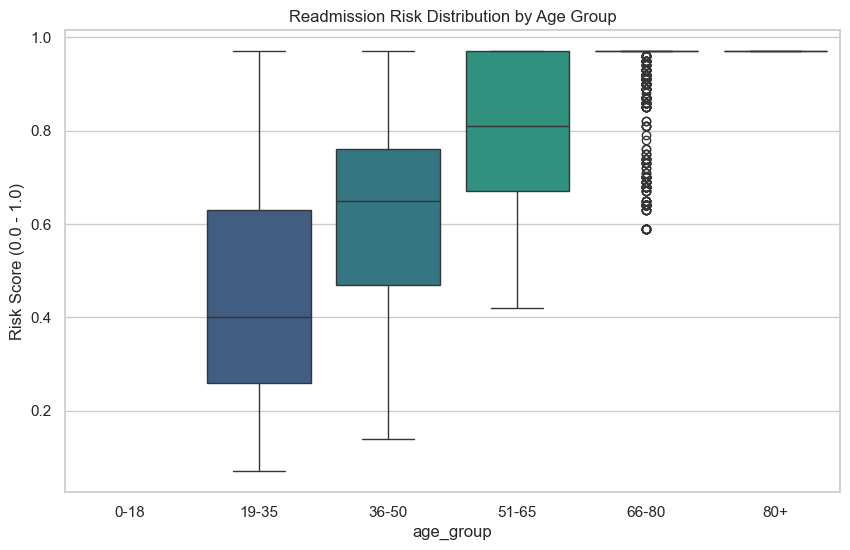

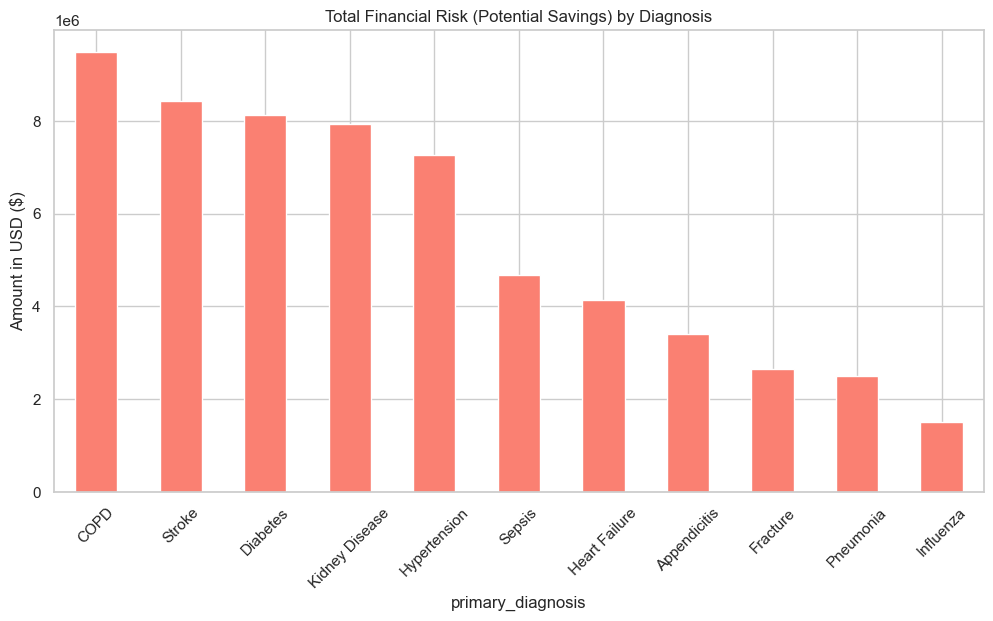

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Visual A: Risk Score Distribution by Age Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='age_group', y='readmission_risk_score', palette='viridis')
plt.title('Readmission Risk Distribution by Age Group')
plt.ylabel('Risk Score (0.0 - 1.0)')
plt.show()

# Visual B: Financial Risk by Diagnosis
# This shows where the hospital is "losing" the most potential money
plt.figure(figsize=(12, 6))
risk_by_diag = df.groupby('primary_diagnosis')['potential_savings'].sum().sort_values(ascending=False)
risk_by_diag.plot(kind='bar', color='salmon')
plt.title('Total Financial Risk (Potential Savings) by Diagnosis')
plt.ylabel('Amount in USD ($)')
plt.xticks(rotation=45)
plt.show()

In [7]:
# Use the exact column name: 'comorbidities_count'
def comorbidity_level(count):
    if count <= 2: return 'Low'
    elif count <= 5: return 'Moderate'
    else: return 'High/Complex'

df['comorbidity_severity'] = df['comorbidities_count'].apply(comorbidity_level)

print("Success! 'comorbidity_severity' column created.")

Success! 'comorbidity_severity' column created.


In [8]:
# --- Age Grouping ---
bins = [0, 18, 35, 50, 65, 80, 120]
labels = ['0-18', '19-35', '36-50', '51-65', '66-80', '80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# --- Length of Stay (LoS) Categorization ---
def categorize_stay(days):
    if days <= 3: return 'Short Stay (1-3 days)'
    elif days <= 7: return 'Standard (4-7 days)'
    else: return 'Extended (8+ days)'

df['stay_category'] = df['length_of_stay'].apply(categorize_stay)

# --- Comorbidity Severity (FIXED NAME HERE) ---
def comorbidity_level(count):
    if count <= 2: return 'Low'
    elif count <= 5: return 'Moderate'
    else: return 'High/Complex'

# I changed 'comorbidities' to 'comorbidities_count'
df['comorbidity_severity'] = df['comorbidities_count'].apply(comorbidity_level)

# --- Seasonality ---
df['admission_month_num'] = df['admission_date'].dt.month 

print("New Features Created Successfully!")
df[['patient_id', 'age_group', 'stay_category', 'comorbidity_severity']].head()

New Features Created Successfully!


,patient_id,age_group,stay_category,comorbidity_severity
0,P00001,66-80,Standard (4-7 days),Moderate
1,P00002,51-65,Standard (4-7 days),Moderate
2,P00003,66-80,Extended (8+ days),High/Complex
3,P00004,80+,Extended (8+ days),High/Complex
4,P00005,51-65,Extended (8+ days),Moderate


In [9]:
final_output = r"C:\Users\Dell\Documents\ANALYTICS PRACTICE\PROJECT\HealthCare Project\processed_healthcare_data_2026.csv"
df.to_csv(final_output, index=False)

print(f"Project Data Saved as: {final_output}")

Project Data Saved as: C:\Users\Dell\Documents\ANALYTICS PRACTICE\PROJECT\HealthCare Project\processed_healthcare_data_2026.csv
